Dataset acquired from the following link: https://www.kaggle.com/competitions/bike-sharing-demand/

In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [109]:
import time
import copy

In [111]:
import optuna

In [112]:
df = pd.read_csv("./datasets/bike-sharing/train.csv")

In [113]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [114]:
df.shape

(10886, 12)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [116]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [117]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [118]:
df.duplicated().sum()

np.int64(0)

In [119]:
print(df["season"].value_counts())
print()
print(df["holiday"].value_counts())
print()
print(df["workingday"].value_counts())
print()
print(df["weather"].value_counts())

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

holiday
0    10575
1      311
Name: count, dtype: int64

workingday
1    7412
0    3474
Name: count, dtype: int64

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


<Axes: xlabel='weather', ylabel='count'>

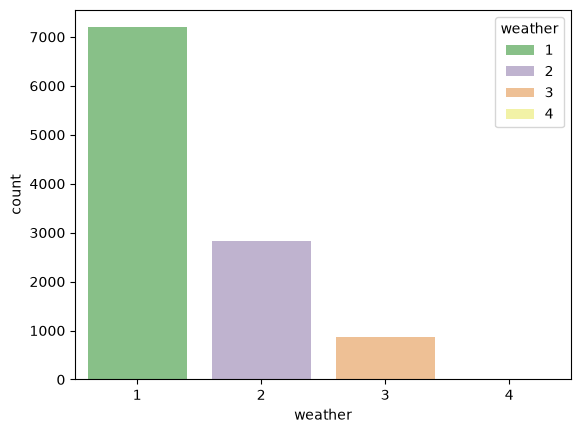

In [120]:
sns.countplot(x=df["weather"],hue=df["weather"],palette="Accent")

Severe Data Imbalance between different weather types

<Axes: xlabel='count', ylabel='Count'>

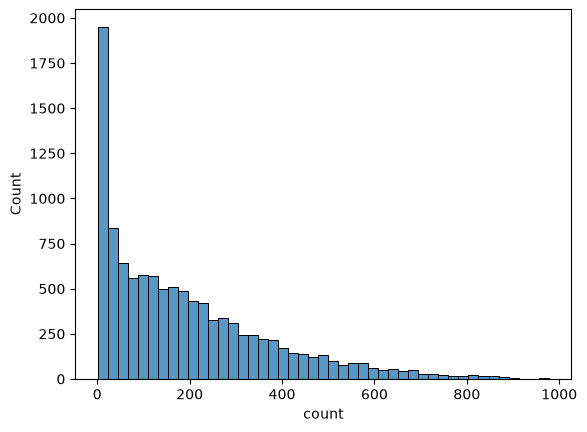

In [121]:
sns.histplot(data=df,x="count")

Our target is skewed to the right

1.2420662117180776 -0.8514116321738534


<Axes: xlabel='count', ylabel='Count'>

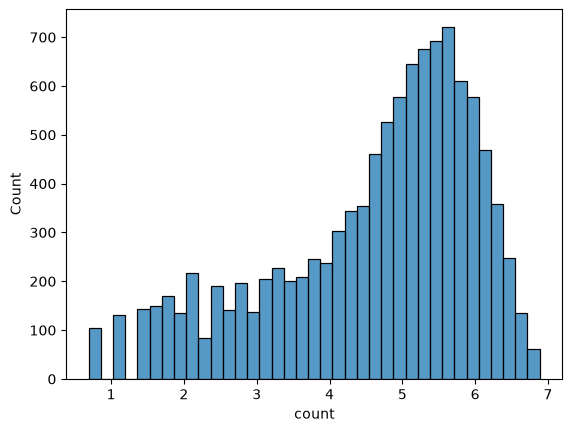

In [170]:
temp_df = np.log1p(df["count"])
skew = df["count"].skew()
skew_log = temp_df.skew()
print(skew,skew_log)
sns.histplot(temp_df)

Using Log1p to fix skewness overcorrects and the data now has a negative skew

1.2420662117180776 0.25764327133235915


<Axes: xlabel='count', ylabel='Count'>

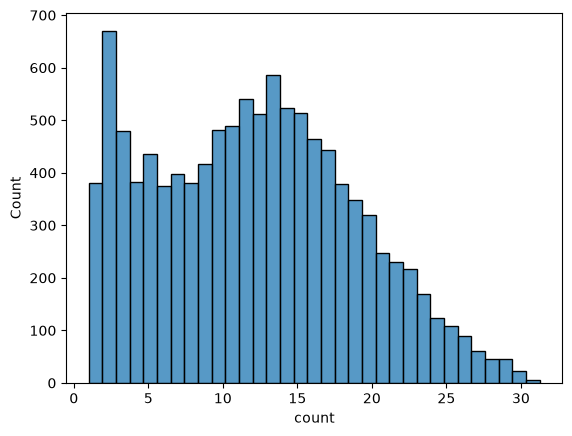

In [123]:
temp_df = np.sqrt(df["count"])
skew = df["count"].skew()
skew_log = temp_df.skew()
print(skew,skew_log)
sns.histplot(temp_df)

Using square root corrects the data to a more consistent form.

<Axes: xlabel='season', ylabel='count'>

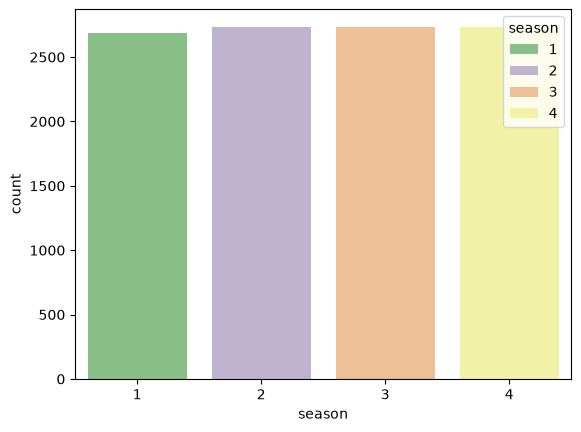

In [124]:
sns.countplot(x=df["season"],hue=df["season"],palette="Accent")

Data is balanced between different seasons

<Axes: xlabel='holiday', ylabel='count'>

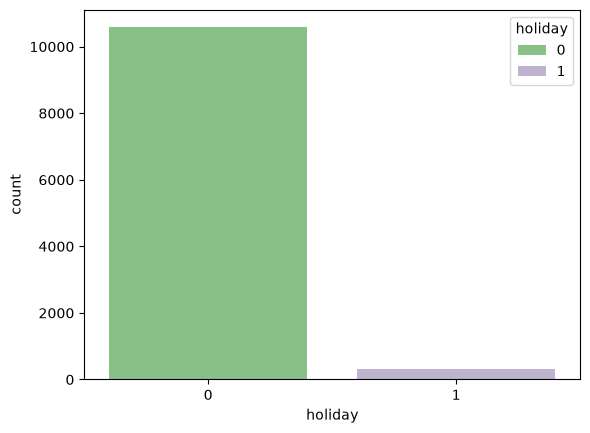

In [125]:
sns.countplot(x=df["holiday"],hue=df["holiday"],palette="Accent")

Severe data imbalance between holiday and non holiday (expected)

<Axes: xlabel='workingday', ylabel='count'>

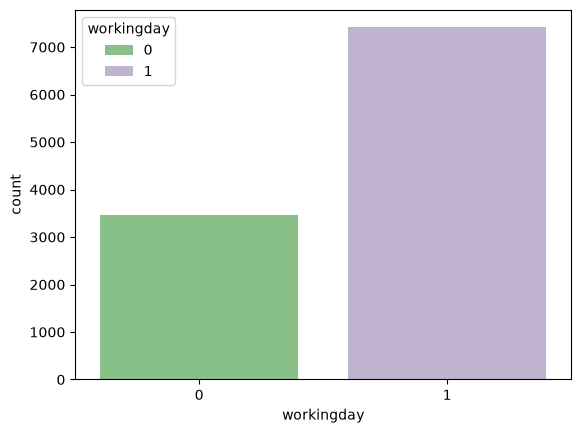

In [126]:
sns.countplot(x=df["workingday"],hue=df["workingday"],palette="Accent")

Imbalance of data between workingday and non workingday (expected)

In [127]:
corr_df = df.copy().drop(columns=["datetime","season","holiday","workingday","weather"])
corr_df.head()

,temp,atemp,humidity,windspeed,casual,registered,count
0,9.84,14.395,81,0.0,3,13,16
1,9.02,13.635,80,0.0,8,32,40
2,9.02,13.635,80,0.0,5,27,32
3,9.84,14.395,75,0.0,3,10,13
4,9.84,14.395,75,0.0,0,1,1


<Axes: >

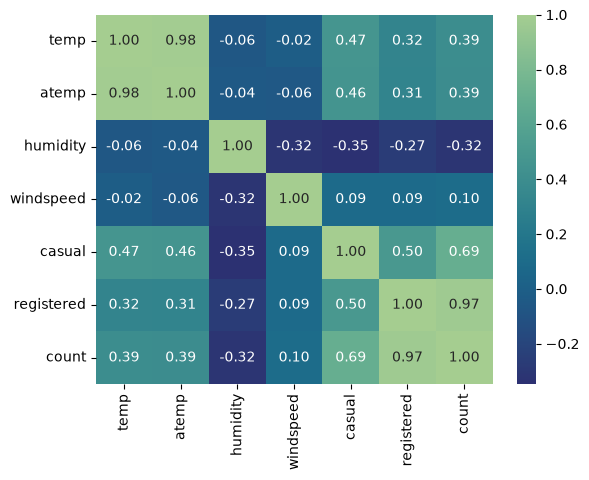

In [128]:
corr = corr_df.corr()
sns.heatmap(corr,annot=True,fmt=".2f",cmap="crest_r")

1. Seen slight positive correlation between temperatures and number of casual (non-registered) users.
2. Seen slight negative correlation between humidity and users overall.
3. Count is the sum of Registered and Casual users, this will cause data leakage if used for training.

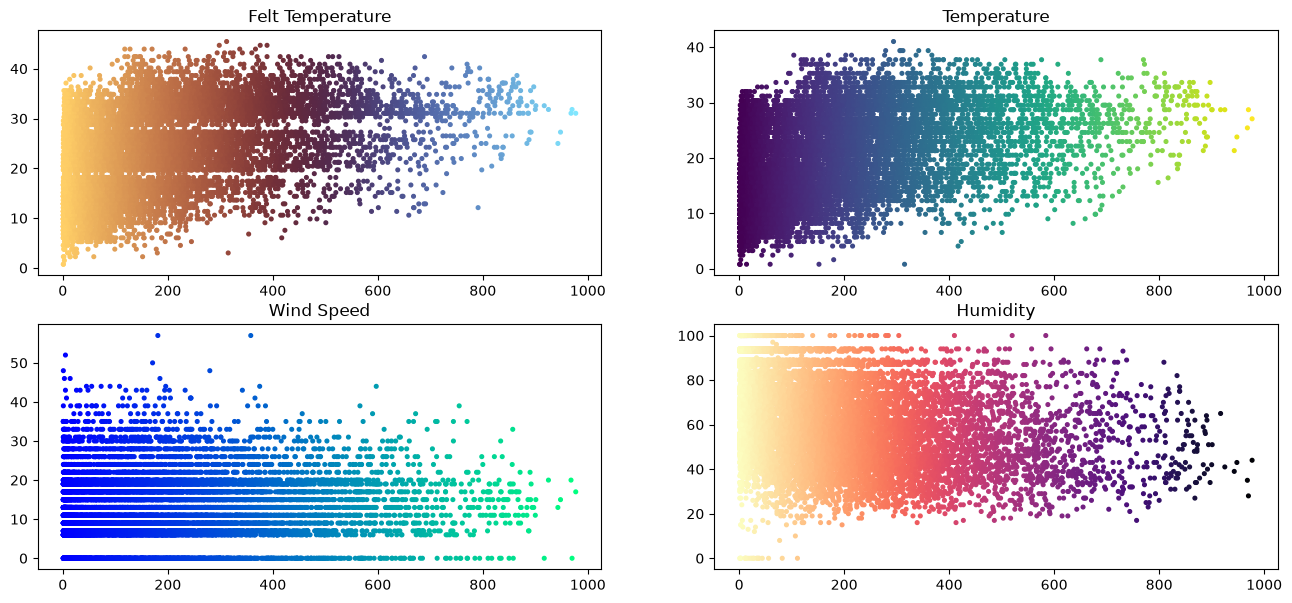

In [129]:
fig, ax = plt.subplots(2,2,figsize=(16,7))
ax[0,0].scatter(df["count"], df["atemp"],marker="o",s=7,c=df["count"], cmap="managua")
ax[0,0].set_title("Felt Temperature")

ax[0,1].scatter(df["count"], df["temp"],marker="o",s=7,c=df["count"], cmap="viridis")
ax[0,1].set_title("Temperature")

ax[1,0].scatter(df["count"], df["windspeed"],marker="o",s=7,c=df["count"], cmap="winter")
ax[1,0].set_title("Wind Speed")

ax[1,1].scatter(df["count"], df["humidity"],marker="o",s=7,c=df["count"], cmap="magma_r")
ax[1,1].set_title("Humidity")

plt.show()

Seen Trends:
1. Generally more people rent more at 20 - 40 celcius
2. Generally people rent more at less wind speeds
3. No trends between humidity and count unless at very low humidity

<Axes: xlabel='weather', ylabel='count'>

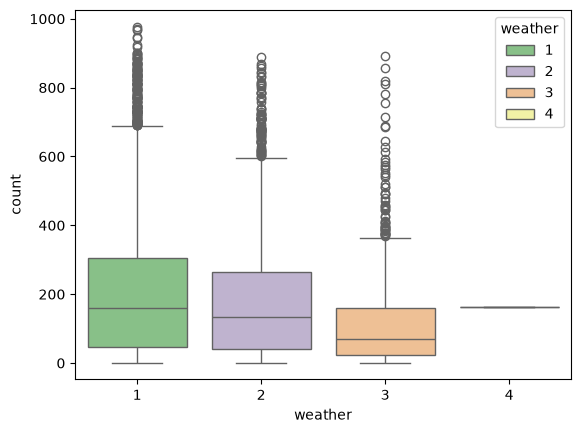

In [130]:
sns.boxplot(data=df, x="weather",y="count",hue="weather",palette="Accent")

More bikes are rented generally in clear weather compared to others. For weather status 4 there is only one entry.

In [131]:
df.groupby("weather")["count"].agg(["min","max"])

,min,max
weather,,
1,1,977
2,1,890
3,1,891
4,164,164


In [132]:
df = pd.get_dummies(data=df,columns=["weather","season","holiday","workingday"])

In [133]:
df

,datetime,temp,atemp,humidity,windspeed,casual,registered,count,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4,holiday_0,holiday_1,workingday_0,workingday_1
0,2011-01-01 00:00:00,9.84,14.395,81,0.0000,3,13,16,True,False,False,False,True,False,False,False,True,False,True,False
1,2011-01-01 01:00:00,9.02,13.635,80,0.0000,8,32,40,True,False,False,False,True,False,False,False,True,False,True,False
2,2011-01-01 02:00:00,9.02,13.635,80,0.0000,5,27,32,True,False,False,False,True,False,False,False,True,False,True,False
3,2011-01-01 03:00:00,9.84,14.395,75,0.0000,3,10,13,True,False,False,False,True,False,False,False,True,False,True,False
4,2011-01-01 04:00:00,9.84,14.395,75,0.0000,0,1,1,True,False,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,15.58,19.695,50,26.0027,7,329,336,True,False,False,False,False,False,False,True,True,False,False,True
10882,2012-12-19 20:00:00,14.76,17.425,57,15.0013,10,231,241,True,False,False,False,False,False,False,True,True,False,False,True
10883,2012-12-19 21:00:00,13.94,15.910,61,15.0013,4,164,168,True,False,False,False,False,False,False,True,True,False,False,True
10884,2012-12-19 22:00:00,13.94,17.425,61,6.0032,12,117,129,True,False,False,False,False,False,False,True,True,False,False,True


In [134]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute

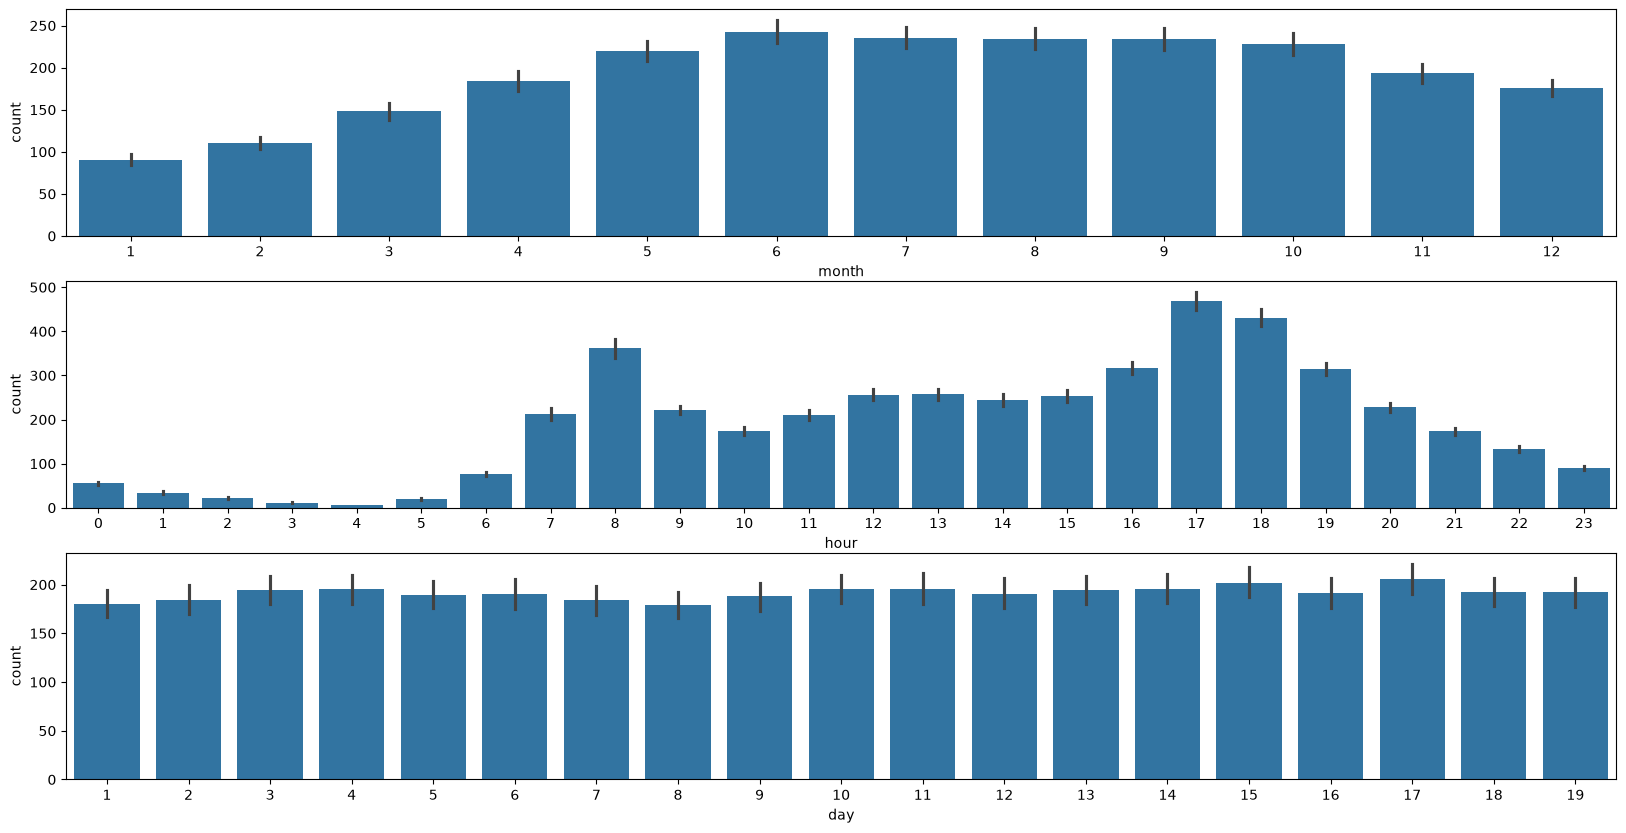

In [169]:
fig, axes = plt.subplots(3,figsize=(20,10))
sns.barplot(data=df,x="month",y="count",ax=axes[0])
sns.barplot(data=df,x="hour",y="count",ax=axes[1])
sns.barplot(data=df,x="day",y="count",ax=axes[2])

plt.show()

1. It can be seen that the number of bikes rented is largely the same across all days of the month.
2. There are more bikes rented in the middle of the year compared to the ends, presumably due to warmer weather.
3. Expectedly, there are far less bikes rented during non-active/night hours of the day compared to daytime.

In [136]:
df["month"].value_counts()

month
5     912
6     912
7     912
8     912
12    912
10    911
11    911
4     909
9     909
2     901
3     901
1     884
Name: count, dtype: int64

In [137]:
x = df.drop(columns=["datetime","casual","registered","count"])
y = df["count"]

In [138]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [139]:
scaler = StandardScaler()

In [140]:
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [145]:
x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(np.log1p(y_train.to_numpy()), dtype=torch.float32).view(-1,1)
y_test_t = torch.tensor(np.log1p(y_test.to_numpy()), dtype=torch.float32).view(-1,1)

In [146]:
class BikeData(Dataset):
    def __init__(self, x,y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [147]:
train_dataset = BikeData(x_train_t,y_train_t)
test_dataset = BikeData(x_test_t, y_test_t)

In [148]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [149]:
n_features = x_train_t.shape[1]
n_features

21

In [150]:
class BikeNN(nn.Module):
    def __init__(self, n, hidden_sizes=(64, 32, 16)):
        super().__init__()
        layers = []
        prev = n
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [151]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [152]:
model = BikeNN(n_features).to(device)

In [153]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [154]:
def epochOne(model, loader, optimizer):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch,y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
    return running_loss/len(loader.dataset)

In [155]:
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch,y_batch = x_batch.to(device),y_batch.to(device)

            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * x_batch.size(0)

    return running_loss/len(loader.dataset)

In [156]:
def evaluate_real(model, loader):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu())
            actuals.append(y_batch.cpu())

    preds = torch.expm1(torch.cat(preds)).numpy()
    actuals = torch.expm1(torch.cat(actuals)).numpy()
    preds = np.clip(preds, 0, None)

    rmse = np.sqrt(np.mean((preds-actuals)**2))
    mae = np.mean(np.abs(preds-actuals))

    return rmse,mae

In [157]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta = 1e-4):
        self.patience=patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [158]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    hidden_sizes = trial.suggest_categorical("hidden_sizes", [(64,32,16), (128,64,32), (32,16,8)])

    train_loader_ = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader_ = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    trial_model = BikeNN(n_features, hidden_sizes).to(device)
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopper = EarlyStopping(patience=8)

    for epoch in range(100):
        epochOne(trial_model, train_loader_, optimizer)
        val_loss = evaluate(trial_model, test_loader_)
        early_stopper(val_loss, trial_model)
        if early_stopper.early_stop:
            break

    early_stopper.restore_best(trial_model)
    return early_stopper.best_loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best params:", study.best_params)
print("Best val loss:", study.best_value)

[I 2026-09-23 11:05:23,174] A new study created in memory with name: no-name-f059af94-d596-4e23-ae9f-3facaba37cb1
/tmp/ipykernel_29042/978474342.py:5: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 32, 16) which is of type tuple.
  hidden_sizes = trial.suggest_categorical("hidden_sizes", [(64,32,16), (128,64,32), (32,16,8)])
/tmp/ipykernel_29042/978474342.py:5: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128, 64, 32) which is of type tuple.
  hidden_sizes = trial.suggest_categorical("hidden_sizes", [(64,32,16), (128,64,32), (32,16,8)])
/tmp/ipykernel_29042/978474342.py:5: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 16, 8) which is of type tuple.
  hidden_sizes = trial.suggest_categorical("hidden

Best params: {'lr': 0.0006436224542323335, 'weight_decay': 0.0006479940822955607, 'batch_size': 32, 'hidden_sizes': (128, 64, 32)}
Best val loss: 0.1145995422390429


Final Parameters have been found as:
1. Hidden layers with feautres: input features -> 128 -> 64 -> 32 -> Output
2. Learning rate for model: 0.0006436224542323335
3. Weight Decay: 0.0006479940822955607
4. Data Loader batch size: 32

In [159]:
class BikeNN_final(nn.Module):
    def __init__(self, n, hidden_sizes=(128, 64, 32)):
        super().__init__()
        layers = []
        prev = n
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [160]:
model_final = BikeNN_final(n_features).to(device)

In [161]:
optimizer_final = torch.optim.Adam(model_final.parameters(), lr=0.0006436224542323335, weight_decay=0.0006479940822955607)
train_loader_final = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader_final = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [162]:
history ={
    "train_loss":[],
    "val_loss":[]
}
epochs = 100
total_start = time.time()

early_stopper = EarlyStopping(patience=12)

for epoch in range(epochs):
    start = time.time()
    train_loss = epochOne(model_final, train_loader_final, optimizer_final)
    val_loss = evaluate(model_final, test_loader_final)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(  f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f} | "
            f"{time.time()-start:.0f} sec"
          )
    
    early_stopper(val_loss, model_final)
    total_time = time.time() - total_start
    if early_stopper.early_stop:
        print(f"\n\nStopping at epoch: {epoch+1} | Best val loss: {early_stopper.best_loss:.4f}")
        break
print(f"\nTraining Time: {total_time:.1f}s | {total_time / 60:.2f} minutes")
early_stopper.restore_best(model_final)
rmse,mae=evaluate_real(model_final,test_loader_final)
print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f}")

Epoch 1/100 | Train Loss: 6.6155 | Validation Loss: 1.2854 | 0 sec
Epoch 2/100 | Train Loss: 1.3027 | Validation Loss: 1.1616 | 0 sec
Epoch 3/100 | Train Loss: 1.1742 | Validation Loss: 1.1836 | 0 sec
Epoch 4/100 | Train Loss: 1.0936 | Validation Loss: 1.0683 | 0 sec
Epoch 5/100 | Train Loss: 1.0117 | Validation Loss: 0.9833 | 0 sec
Epoch 6/100 | Train Loss: 0.8985 | Validation Loss: 0.8846 | 0 sec
Epoch 7/100 | Train Loss: 0.7864 | Validation Loss: 0.7809 | 0 sec
Epoch 8/100 | Train Loss: 0.7060 | Validation Loss: 0.6999 | 0 sec
Epoch 9/100 | Train Loss: 0.6598 | Validation Loss: 0.6544 | 0 sec
Epoch 10/100 | Train Loss: 0.6107 | Validation Loss: 0.6195 | 0 sec
Epoch 11/100 | Train Loss: 0.5724 | Validation Loss: 0.5785 | 0 sec
Epoch 12/100 | Train Loss: 0.5256 | Validation Loss: 0.5647 | 0 sec
Epoch 13/100 | Train Loss: 0.4902 | Validation Loss: 0.5123 | 0 sec
Epoch 14/100 | Train Loss: 0.4497 | Validation Loss: 0.4470 | 0 sec
Epoch 15/100 | Train Loss: 0.4083 | Validation Loss: 0.41

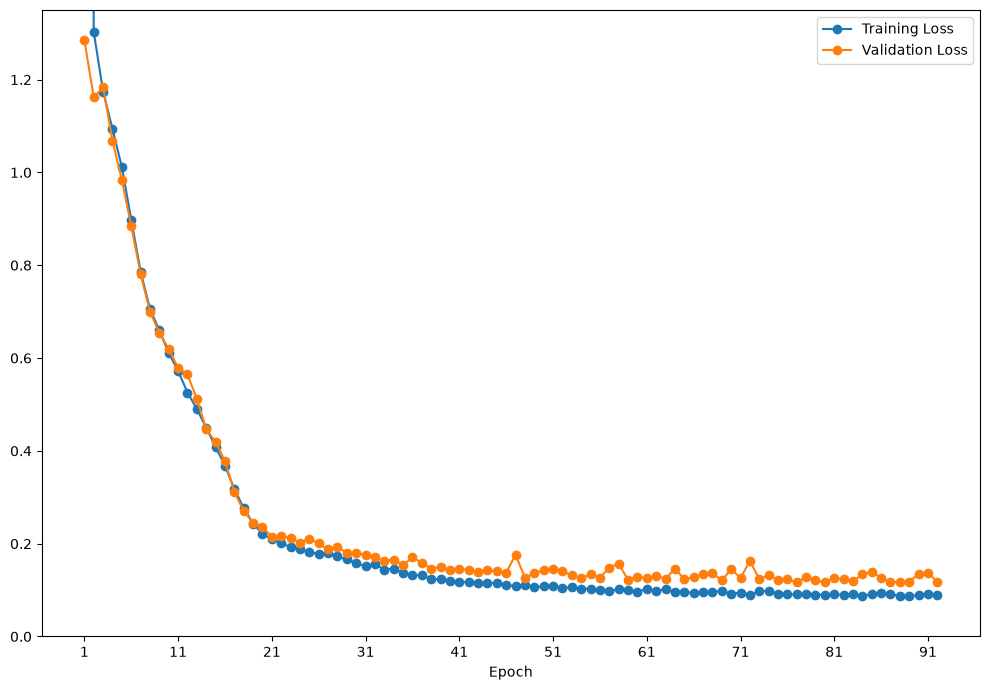

In [173]:
epochs = list(range(1,len(history["train_loss"])+1))
plt.figure(figsize=(10,7))
plt.plot(
    epochs,
    [Tloss for Tloss in history["train_loss"]],
    label="Training Loss",
    marker="o"
)
plt.plot(
    epochs,
    [Tloss for Tloss in history["val_loss"]],
    label="Validation Loss",
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("")

plt.xticks(epochs[0::10])
plt.ylim(0,1.35)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
torch.save({
    "model_state_dict":model_final.state_dict(),
    "n_features":n_features,
    "scaler_mean":scaler.mean_,
    "scaler_scale":scaler.scale_,
    "feature_names":list(x.columns)
}, "./models/bike_model.pt" )